In [197]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt 
%matplotlib inline

In [198]:
words=open('names.txt','r').read().splitlines()

In [199]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}        
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [200]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [201]:

n_embed=10
n_hidden=200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embed), generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden), generator=g)*0.01
b1 = torch.randn(n_hidden, generator=g)*0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.01
b2 = torch.randn(vocab_size, generator=g)*0
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

11897


In [202]:
max_steps = 200000  
batch_size=32

lri=[]
lossi=[]
for _ in range(1000):
    #minibatch gradient descent
    ix=torch.randint(0, Xte.shape[0], (batch_size,))
    Xb,Yb=Xte[ix], Yte[ix]
    emb=C[Xb]
    hpreact=emb.view(emb.shape[0], -1) @ W1 + b1
    h=torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss=F.cross_entropy(logits, Yb)
    for p in parameters:
        p.grad = None
    loss.backward()
    # lr=lrs[_]
    lr=0.1 if _ < 100000  else 0.01
    for p in parameters:
        p.data += -lr * p.grad 
    if _ % 100 == 0:
        print(loss.item())
    # lri.append(lre[_].item())
    # lossi.append(loss.item())

    break
  

3.295032262802124


(array([  2.,   0.,   1.,   2.,   0.,   6.,   9.,  14.,  14.,  13.,  16.,
         24.,  58.,  67.,  96., 114., 153., 176., 250., 234., 286., 314.,
        368., 379., 437., 410., 415., 389., 396., 345., 286., 258., 190.,
        162., 129., 108.,  77.,  64.,  38.,  35.,  17.,  11.,  13.,   7.,
          5.,   6.,   2.,   0.,   1.,   3.]),
 array([-0.21480793, -0.2061817 , -0.19755548, -0.18892926, -0.18030303,
        -0.17167681, -0.16305059, -0.15442437, -0.14579814, -0.13717192,
        -0.1285457 , -0.11991947, -0.11129325, -0.10266703, -0.0940408 ,
        -0.08541458, -0.07678836, -0.06816213, -0.05953591, -0.05090969,
        -0.04228346, -0.03365724, -0.02503102, -0.01640479, -0.00777857,
         0.00084765,  0.00947388,  0.0181001 ,  0.02672632,  0.03535255,
         0.04397877,  0.05260499,  0.06123122,  0.06985744,  0.07848366,
         0.08710988,  0.09573611,  0.10436233,  0.11298855,  0.12161478,
         0.130241  ,  0.13886722,  0.14749345,  0.15611967,  0.16474589,
 

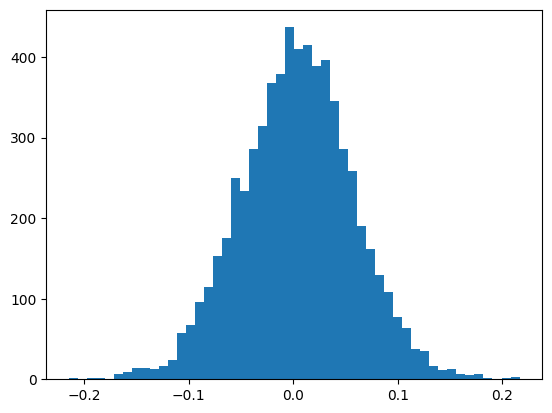

In [203]:
plt.hist(h.view(-1).tolist(), 50)

(array([  2.,   0.,   1.,   2.,   0.,   5.,  10.,   9.,  17.,  10.,  18.,
         22.,  47.,  73.,  88., 108., 159., 175., 251., 242., 277., 325.,
        365., 386., 442., 414., 431., 397., 395., 342., 286., 254., 185.,
        158., 135., 102.,  77.,  60.,  38.,  29.,  18.,  11.,  10.,   8.,
          4.,   6.,   2.,   1.,   0.,   3.]),
 array([-0.21820645, -0.20944263, -0.20067881, -0.191915  , -0.18315118,
        -0.17438736, -0.16562354, -0.15685973, -0.14809591, -0.13933209,
        -0.13056827, -0.12180445, -0.11304064, -0.10427682, -0.095513  ,
        -0.08674918, -0.07798536, -0.06922155, -0.06045773, -0.05169391,
        -0.04293009, -0.03416628, -0.02540246, -0.01663864, -0.00787482,
         0.000889  ,  0.00965281,  0.01841663,  0.02718045,  0.03594427,
         0.04470809,  0.0534719 ,  0.06223572,  0.07099954,  0.07976336,
         0.08852717,  0.09729099,  0.10605481,  0.11481863,  0.12358245,
         0.13234626,  0.14111008,  0.1498739 ,  0.15863772,  0.16740153,
 

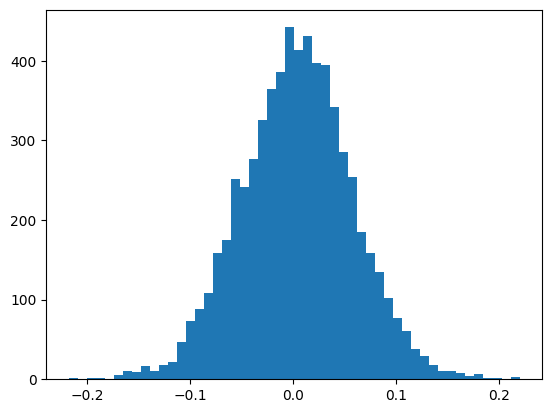

In [204]:
plt.hist(hpreact.view(-1).tolist(), 50)

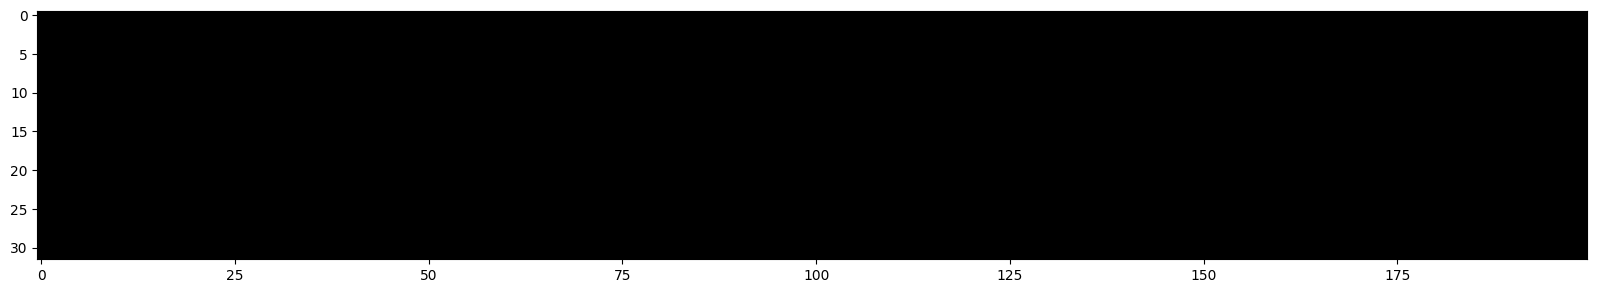

In [205]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99,cmap='gray',interpolation='nearest')

In [206]:
emb=C[Xtr]
print(emb.shape)
h=emb.view(emb.shape[0], -1) @ W1 + b1
h=torch.tanh(h)
logits = h @ W2 + b2  
print(logits.shape)  
print(Ytr.shape)  
loss=F.cross_entropy(logits, Ytr)
loss

torch.Size([182625, 3, 10])
torch.Size([182625, 27])
torch.Size([182625])


tensor(3.2914, grad_fn=<NllLossBackward0>)

In [207]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [208]:
#24:00

# actual code with initilisation correction

In [209]:

n_embed=10
n_hidden=200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embed), generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden), generator=g)*(5/3)/torch.sqrt(torch.tensor(n_embed * block_size))
#b1 = torch.randn(n_hidden, generator=g)*0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.01
b2 = torch.randn(vocab_size, generator=g)*0
bngain=torch.ones((1, n_hidden))
bnbias=torch.zeros((1, n_hidden))
bnmean_running=torch.zeros((1, n_hidden))
bnstd_running=torch.ones((1, n_hidden))
parameters = [C, W1,W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12097


In [210]:
max_steps = 20000 
batch_size=32

lri=[]
lossi=[]
for _ in range(max_steps):
    #minibatch gradient descent
    ix=torch.randint(0, Xte.shape[0], (batch_size,))
    Xb,Yb=Xte[ix], Yte[ix]
    emb=C[Xb]
    embcat=emb.view(emb.shape[0], -1)
    hpreact=embcat @ W1 #+ b1
    bnmeani=hpreact.mean(0, keepdim=True)
    bnstdi=hpreact.std(0, keepdim=True)
    hpreact=bngain*(hpreact - bnmeani) / bnstdi + bnbias  
    with torch.no_grad():
        bnmean_running = 0.999*bnmean_running + 0.001*bnmeani
        bnstd_running = 0.999*bnstd_running + 0.001*bnstdi          
    h=torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss=F.cross_entropy(logits, Yb)
    for p in parameters:
        p.grad = None
    loss.backward()
    # lr=lrs[_]
    lr=0.1 if _ < 100000  else 0.01
    for p in parameters:
       
        p.data += -lr*p.grad 

    
    print(loss.item())
    # lri.append(lre[_].item())
    # lossi.append(loss.item())

   
  

3.2884418964385986
3.233929395675659
3.277665615081787
3.3476037979125977
3.193607807159424
3.172468423843384
3.1878466606140137
3.1732378005981445
3.149726390838623
3.2035484313964844
3.1076173782348633
3.1477115154266357
3.070040464401245
2.9947891235351562
3.0605008602142334
3.1011056900024414
2.9472920894622803
2.802069664001465
2.9730465412139893
2.929541826248169
3.080007791519165
3.1862411499023438
2.903226375579834
3.0540783405303955
2.963233470916748
2.7686965465545654
2.8279757499694824
2.930539608001709
2.980177402496338
3.0796730518341064
2.8157498836517334
3.053999185562134
2.8266077041625977
3.0285491943359375
2.860332489013672
3.0493123531341553
3.050302505493164
2.947828531265259
2.7703356742858887
2.6260886192321777
2.776369571685791
2.887500524520874
2.9801297187805176
3.04622745513916
2.624701976776123
2.9173688888549805
2.955270767211914
2.620582342147827
2.6318185329437256
2.7612218856811523
2.4891624450683594
2.8990626335144043
2.828216552734375
3.1153523921966553

In [211]:
emb=C[Xtr]
print(emb.shape)
embcat=emb.view(emb.shape[0], -1)
hpreact=embcat @ W1 + b1
hpreact=bngain*(hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias            
h=torch.tanh(hpreact)
logits = h @ W2 + b2  
print(logits.shape)  
print(Ytr.shape)  
loss=F.cross_entropy(logits, Ytr)
loss

torch.Size([182625, 3, 10])
torch.Size([182625, 27])
torch.Size([182625])


tensor(2.3105, grad_fn=<NllLossBackward0>)

In [212]:
#calibrate the btach norm
# with torch.no_grad():
#     emb=C[Xtr]
#     embcat=emb.view(emb.shape[0], -1)
#     hpreact=embcat @ W1 + b1
#     bngain.data = hpreact.std(0, keepdim=True)
#     bnbias.data = hpreact.mean(0, keepdim=True)

In [213]:
emb=C[Xdev]
embcat=emb.view(emb.shape[0], -1)
hpreact=embcat @ W1 + b1
hpreact=bngain*(hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias            
h=torch.tanh(hpreact)
logits = h @ W2 + b2    
loss=F.cross_entropy(logits, Ydev)
loss

tensor(2.3151, grad_fn=<NllLossBackward0>)

In [214]:
#41:00

# torchfy

In [215]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        if bias:
            self.bias = torch.zeros(fan_out)
        else:
            self.bias = None
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out +=  self.bias
        return self.out
    def parameters(self):
        if self.bias is not None:
            return [self.weight, self.bias]
        else:
            return [self.weight]

In [216]:
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.gamma = torch.ones((1, dim))
        self.beta = torch.zeros((1, dim))
        self.running_mean = torch.zeros((1, dim))
        self.running_std = torch.ones((1, dim))
        self.training = True
        self.eps = eps
        self.momentum = momentum
    def __call__(self, x):
        if self.training:
            mean = x.mean(0, keepdim=True)
            std = x.std(0, keepdim=True)
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
                self.running_std = (1 - self.momentum) * self.running_std + self.momentum * std
        else:
            mean = self.running_mean
            std = self.running_std
        xhat = (x - mean) / (std + self.eps)
        return self.gamma * xhat + self.beta
    def parameters(self):
        return [self.gamma, self.beta]

In [217]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [218]:
n_embed=10
n_hidden=100
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embed), generator=g)
layers = [
    Linear(n_embed * block_size, n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, vocab_size),BatchNorm1d(n_hidden)]

with torch.no_grad():
    # layers[-1].weight *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *=5/3



parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

47697


In [219]:
max_steps = 200000 
batch_size=32
lossi=[]
ud=[]
for i in range(max_steps):
    #minibatch gradient descent
    ix=torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb,Yb=Xtr[ix], Ytr[ix]
    emb=C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    logits = x
    loss=F.cross_entropy(logits, Yb)
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    lr=0.1 if i < 100000  else 0.01
    for p in parameters:
        p.data += -lr * p.grad 
    if i % 100 == 0:
        print(loss.item())
    lossi.append(loss.item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
    if i >= 1000:
        break

RuntimeError: The size of tensor a (100) must match the size of tensor b (27) at non-singleton dimension 1

layer 1 (      Tanh): mean -0.02, std 0.76, saturated: 20.91%
layer 3 (      Tanh): mean +0.03, std 0.72, saturated: 14.25%
layer 5 (      Tanh): mean +0.00, std 0.73, saturated: 10.91%
layer 7 (      Tanh): mean +0.01, std 0.73, saturated: 12.81%
layer 9 (      Tanh): mean +0.01, std 0.72, saturated: 11.06%


Text(0.5, 1.0, 'activation distribution')

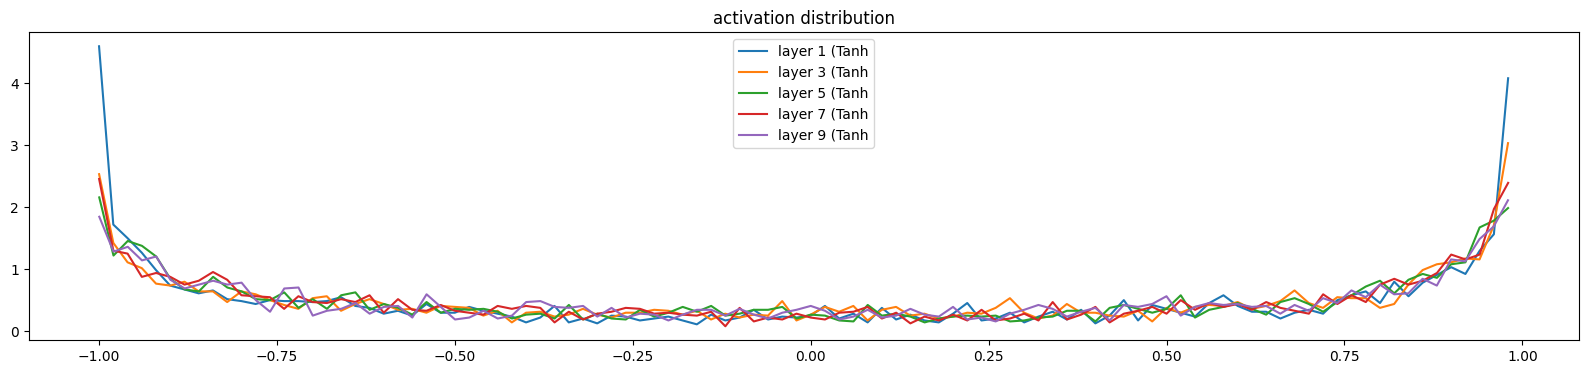

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.000007, std 3.411145e-03
layer 3 (      Tanh): mean -0.000048, std 3.107431e-03
layer 5 (      Tanh): mean +0.000073, std 3.086282e-03
layer 7 (      Tanh): mean +0.000024, std 2.876579e-03
layer 9 (      Tanh): mean -0.000044, std 2.471739e-03


Text(0.5, 1.0, 'gradient distribution')

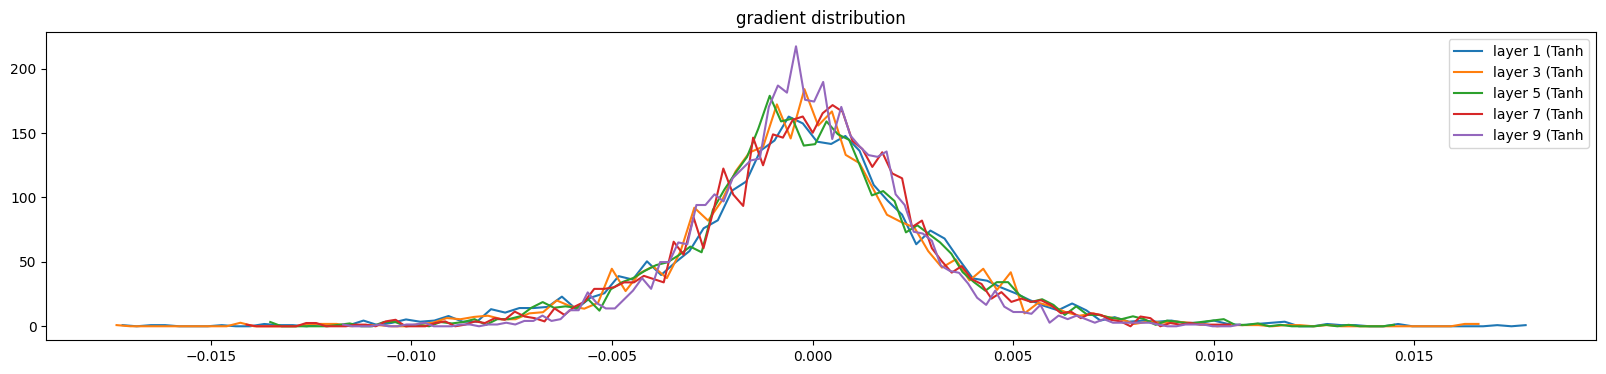

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000302 | std 1.161255e-02 | grad:data ratio 1.160840e-02
weight  (30, 100) | mean +0.000102 | std 1.037073e-02 | grad:data ratio 3.447288e-02
weight (100, 100) | mean +0.000009 | std 8.613498e-03 | grad:data ratio 5.081851e-02
weight (100, 100) | mean +0.000012 | std 7.521452e-03 | grad:data ratio 4.487885e-02
weight (100, 100) | mean -0.000036 | std 6.775051e-03 | grad:data ratio 4.017980e-02
weight (100, 100) | mean -0.000082 | std 5.646486e-03 | grad:data ratio 3.389192e-02
weight  (100, 27) | mean +0.000000 | std 2.311059e-02 | grad:data ratio 3.351985e-01


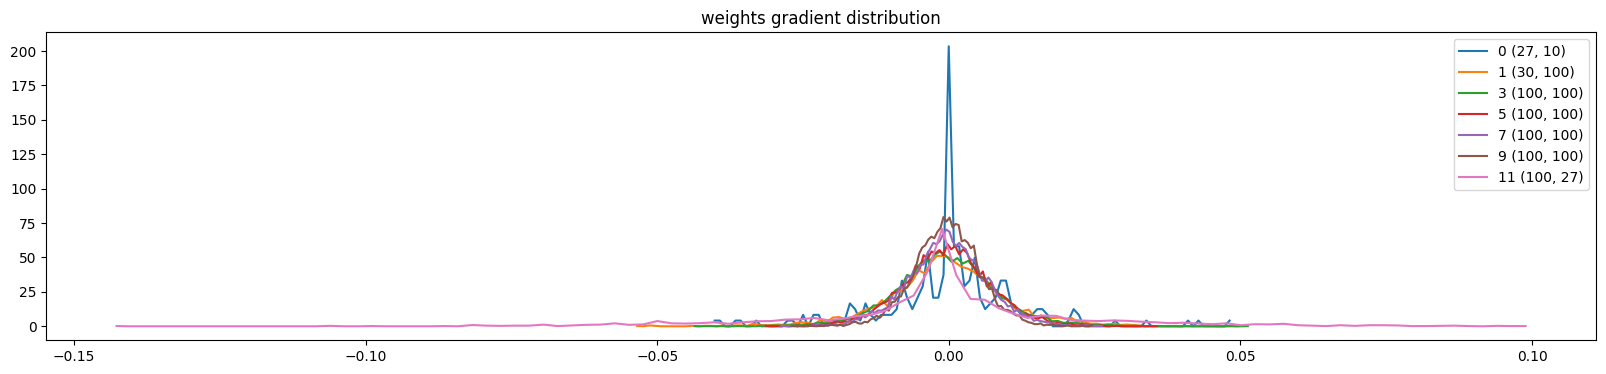

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

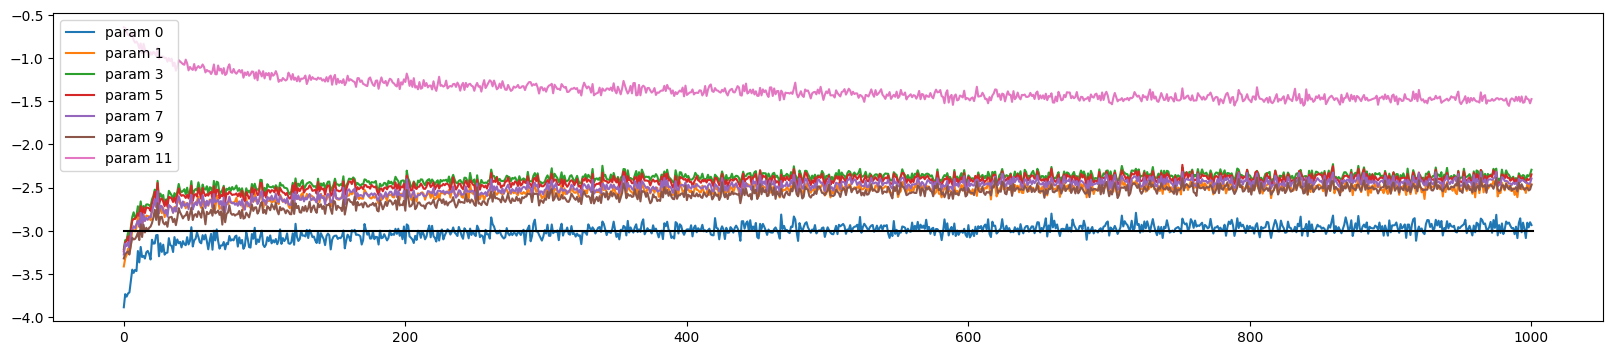

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);